# BHARATH BUILDS — 21 DAYS TO ML ENGINEER
## DAY 7 — DECISION TREES

| Section | Details |
|---|---|
| **Channel** | BHARATH BUILDS |
| **Series** | 21 DAYS TO ML ENGINEER |
| **Day** | DAY 7 |
| **Topic** | Decision Trees |
| **Objective** | Understand how a Decision Tree creates rule-based predictions and controls model complexity. |
| **Dataset** | Breast Cancer Dataset — `sklearn.datasets.load_breast_cancer()` |
| **Problem Type** | Binary Classification |
| **Model** | `DecisionTreeClassifier` |
| **Main Hyperparameter** | `max_depth` |
| **Evaluation** | Accuracy, Confusion Matrix, Classification Report |
| **Visualization** | Decision Tree Structure + Feature Importance |
| **Scaling Required?** | No, Decision Trees generally do not require feature scaling. |

---

## DAY 7 OBJECTIVES

| # | Objective |
|---|---|
| 1 | Understand Decision Tree as a rule-based supervised learning algorithm |
| 2 | Understand Nodes, Branches, and Leaves |
| 3 | Understand how Decision Tree creates splits |
| 4 | Understand Impurity |
| 5 | Understand Gini Impurity |
| 6 | Understand Entropy |
| 7 | Understand Information Gain intuition |
| 8 | Understand Recursive Splitting |
| 9 | Understand Tree Depth |
| 10 | Understand Overfitting and Underfitting |
| 11 | Understand `max_depth` and stopping conditions |
| 12 | Understand Pruning concepts |
| 13 | Understand Feature Importance and its limitations |
| 14 | Train and evaluate a Decision Tree using Scikit-learn |
| 15 | Compare different `max_depth` values |
| 16 | Visualize the trained Decision Tree |

---

## PART 1 — WHITEBOARD THEORY

| Topic | Key Concept |
|---|---|
| **Decision Tree** | Rule-based supervised learning |
| **Tree Structure** | Root → Nodes → Branches → Leaves |
| **Splits** | Divide data using feature-based conditions |
| **Impurity** | Measures how mixed the classes are |
| **Gini Impurity** | Measures node impurity |
| **Entropy** | Measures uncertainty/disorder |
| **Information Gain** | Reduction in impurity/uncertainty after a split |
| **Recursive Splitting** | Repeatedly finding better splits |
| **Tree Depth** | Controls model complexity |
| **Overfitting** | Very deep tree learns overly specific patterns |
| **Underfitting** | Very shallow tree cannot capture enough patterns |
| **Stopping Conditions** | Controls tree growth |
| **Pruning** | Reduces unnecessary tree complexity |
| **Feature Importance** | Shows features used strongly in tree splitting |
| **Decision Tree vs KNN** | Rule-based learning vs distance-based learning |

---

## PART 2 — GOOGLE COLAB PRACTICAL

| Step | Practical |
|---|---|
| **1** | Import required libraries |
| **2** | Load Breast Cancer dataset |
| **3** | Separate Features `X` and Target `y` |
| **4** | Perform minimum dataset check |
| **5** | Train/Test Split |
| **6** | Train `DecisionTreeClassifier` |
| **7** | Generate predictions |
| **8** | Evaluate model accuracy |
| **9** | Check tree depth and number of leaves |
| **10** | Experiment with different `max_depth` values |
| **11** | Compare Training vs Testing Accuracy |
| **12** | Visualize `max_depth` performance |
| **13** | Train final Decision Tree |
| **14** | Visualize the complete Decision Tree |
| **15** | Inspect Feature Importance |
| **16** | Visualize Top Feature Importances |
| **17** | Generate Confusion Matrix |
| **18** | Generate Classification Report |

---

## DATASET

### Breast Cancer Dataset

```python
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = data.data
y = data.target

step 1: import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

step 2: load the dataset

In [2]:
data=load_breast_cancer()

X=pd.DataFrame(data.data, columns=data.feature_names)

y=pd.Series(data.target,name="target")

step 3: mimimum dataset check

In [4]:
print(X.head())
print(X.info())
print(X.shape)
print(X.describe())
print(X.isnull().sum())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

step4: train test split

In [8]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("training data:",X_train.shape)
print("testing data:",X_test.shape)

training data: (455, 30)
testing data: (114, 30)


step 5: Train first decision Tree

In [9]:
model=DecisionTreeClassifier(random_state=42)
model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

step 6: make predictions

In [10]:
y_pred=model.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.9122807017543859


step 7: check the deepth of tree

In [12]:
print("tree depth",model.get_depth())

print("number of leaves:",model.get_n_leaves())

tree depth 7
number of leaves: 19


step 8: max_depth experiment

In [14]:
depths=[2,3,5,10,None]

results=[]

for depth in depths:
  model=DecisionTreeClassifier(max_depth=depth,random_state=42)
  model.fit(X_train,y_train)

  results.append({
      "max_depth":depth,
      "train_accuracy":model.score(X_train,y_train),
      "test_accuracy":model.score(X_test,y_test)
  })

  results_df=pd.DataFrame(results)


  print(results_df)

   max_depth  train_accuracy  test_accuracy
0          2        0.958242       0.894737
   max_depth  train_accuracy  test_accuracy
0          2        0.958242       0.894737
1          3        0.975824       0.938596
   max_depth  train_accuracy  test_accuracy
0          2        0.958242       0.894737
1          3        0.975824       0.938596
2          5        0.993407       0.921053
   max_depth  train_accuracy  test_accuracy
0          2        0.958242       0.894737
1          3        0.975824       0.938596
2          5        0.993407       0.921053
3         10        1.000000       0.912281
   max_depth  train_accuracy  test_accuracy
0        2.0        0.958242       0.894737
1        3.0        0.975824       0.938596
2        5.0        0.993407       0.921053
3       10.0        1.000000       0.912281
4        NaN        1.000000       0.912281


step 9 : compare training and testing accuracy score

In [16]:
results_df

,max_depth,train_accuracy,test_accuracy
0,2.0,0.958242,0.894737
1,3.0,0.975824,0.938596
2,5.0,0.993407,0.921053
3,10.0,1.000000,0.912281
4,NaN,1.000000,0.912281


step 10: visualise max_depth:

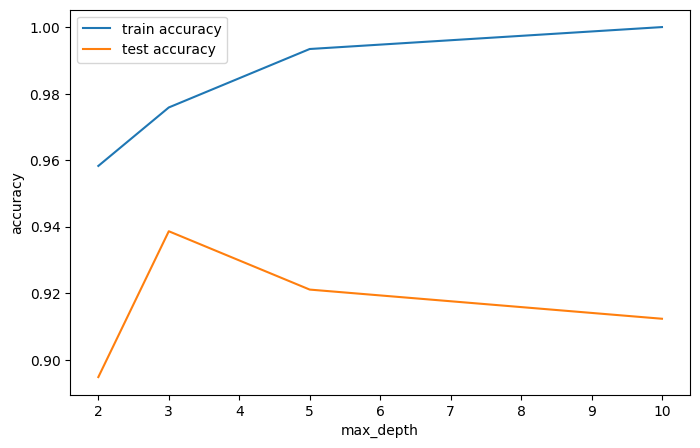

In [18]:
plt.figure(figsize=(8,5))
plt.plot(results_df["max_depth"],results_df["train_accuracy"],label="train accuracy")
plt.plot(results_df["max_depth"],results_df["test_accuracy"],label="test accuracy")
plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.legend()
plt.show()

step11: train final tree

In [19]:
final_model=DecisionTreeClassifier(max_depth=3,random_state=42)
final_model.fit(X_train,y_train)

y_pred=final_model.predict(X_test)

accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)


Accuracy: 0.9385964912280702


step12: visualise the final decision tree

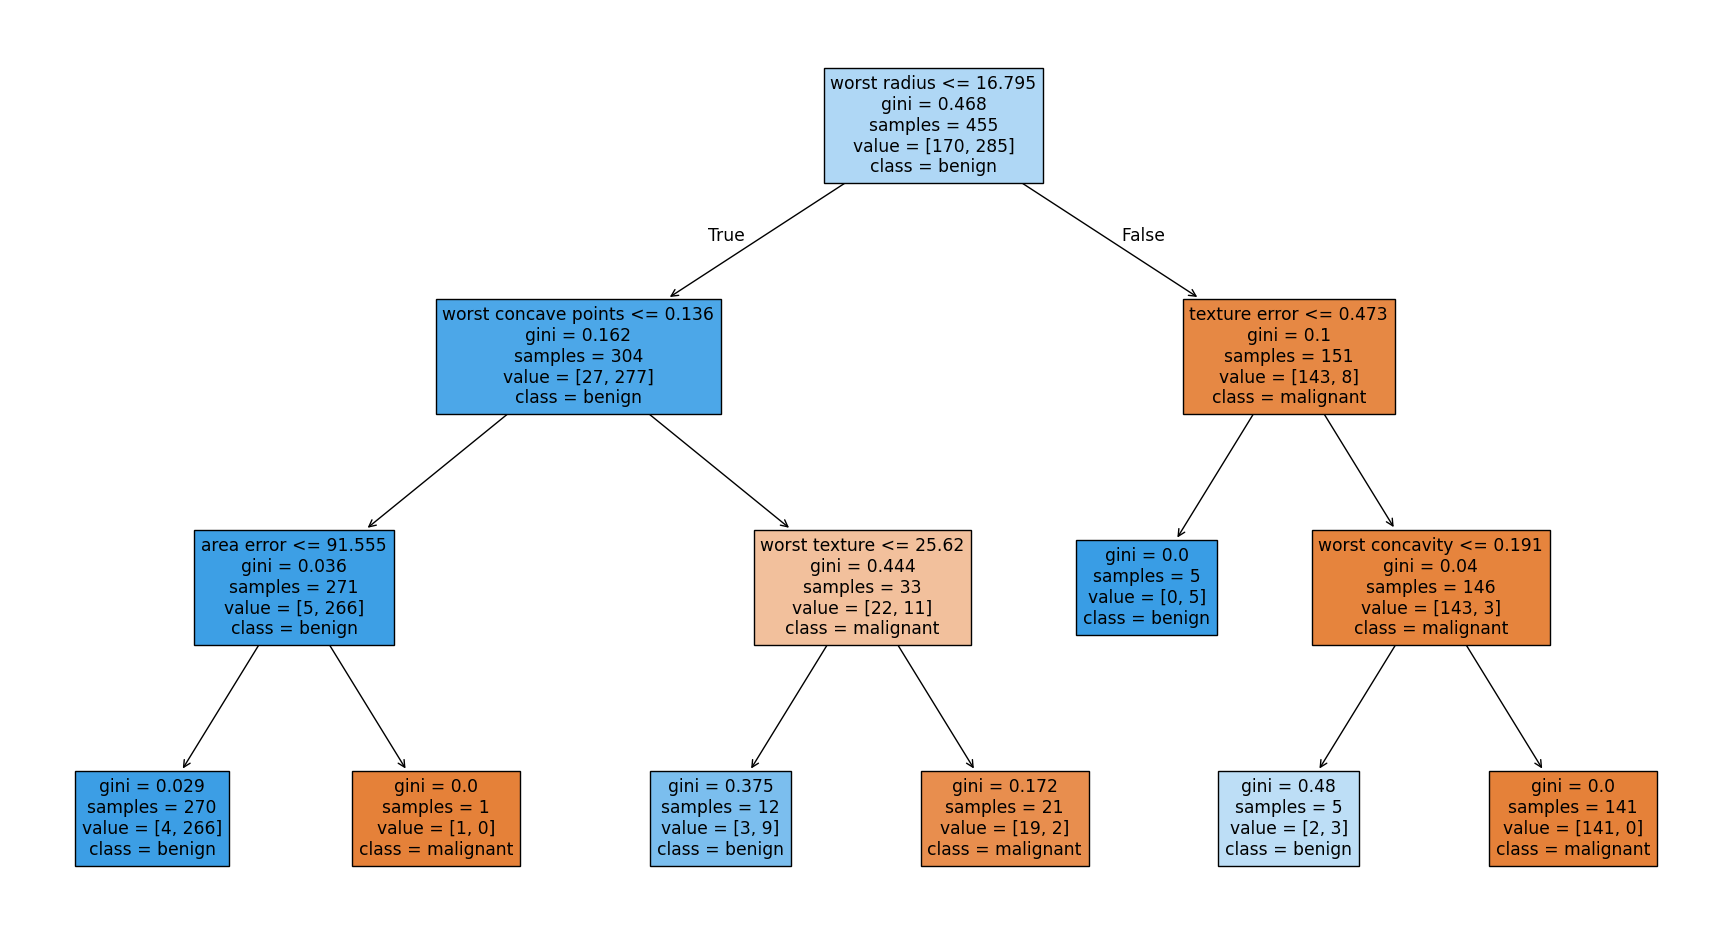

In [20]:
plt.figure(figsize=(22,12))
plot_tree(final_model,filled=True,feature_names=data.feature_names,class_names=["malignant","benign"])
plt.show()

step 14: feature importance

In [22]:
important=pd.Series(final_model.feature_importances_,index=data.feature_names).sort_values(ascending=False)
print(important.head(10))

worst radius            0.763804
worst concave points    0.127061
texture error           0.047673
worst texture           0.033652
worst concavity         0.017869
area error              0.009940
mean compactness        0.000000
mean smoothness         0.000000
mean concavity          0.000000
mean concave points     0.000000
dtype: float64


step15: visualise top features

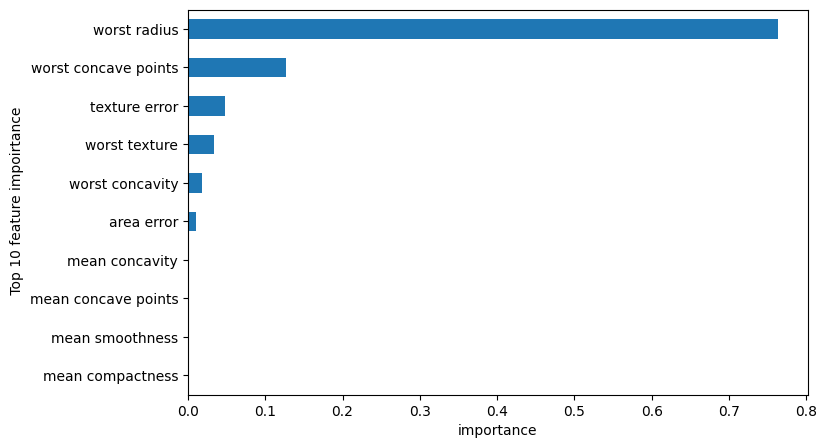

In [23]:
important.head(10).sort_values().plot(kind="barh",figsize=(8,5))
plt.xlabel("importance")
plt.ylabel(" Top 10 feature impoirtance")
plt.show()

step16: confusion matrix

In [25]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[38  4]
 [ 3 69]]


step 17: classification report

In [27]:
print(classification_report(y_test,y_pred,target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        42
      benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



### Interpretation

- **max_depth = 3** gives the best test accuracy: **93.86%**.
- When the tree becomes deeper, **training accuracy reaches 100%**, but test accuracy drops to **91.23%**.
- This shows that a very deep tree can **learn the training data too closely**, leading to overfitting.
- **max_depth = 3** gives a better balance between model complexity and generalization.
- From feature importance, **worst radius** is clearly the most important feature for this trained tree, with much higher importance than the other features.
- The remaining features have relatively small contributions compared with **worst radius**.